# GluonTS (DeepAR, WaveNet, TFT, TFT+covariables) — Reentrenamiento nativo por horizonte

A diferencia de GRU/LSTM/Transformer, estos modelos tienen `prediction_length` fijo en la arquitectura. Para cada horizonte (1, 7, 30 días) se entrena un modelo nuevo con ese `prediction_length`, y se evalúa con walk-forward en bloques de ese mismo tamaño. Son **12 entrenamientos en total** (4 arquitecturas × 3 horizontes) — TFT en CPU es la parte más lenta.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, median_absolute_error, max_error
from gluonts.dataset.common import ListDataset
from gluonts.torch.model.deepar import DeepAREstimator
from gluonts.torch.model.wavenet import WaveNetEstimator
from gluonts.torch.model.tft import TemporalFusionTransformerEstimator

BASE = Path.cwd().parents[1] / 'data' / 'processed'
df = pd.read_parquet(BASE / 'dataset_consolidado.parquet')
df.index = pd.to_datetime(df.index)

FREQ = "D"

train_data = df[df.index < '2025-08-01']['precio_bolsa']
test_data = df[(df.index >= '2025-08-01') & (df.index <= '2026-07-31')]['precio_bolsa']

print(f"Train: {len(train_data)} días")
print(f"Test: {len(test_data)} días")

/opt/anaconda3/envs/tesis-bolsa/lib/python3.12/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


Train: 4595 días
Test: 365 días


In [2]:
# Dataset sin covariables (DeepAR, WaveNet, TFT) — no depende del horizonte
train_ds = ListDataset(
    [{"target": train_data.values, "start": train_data.index[0]}],
    freq=FREQ
)

# Covariables normalizadas (fit SOLO con train, evita el problema de escala que rompía TFT+cov)
covariables = ['gen_termica', 'ONI', 'aportes_energia_gwh']
train_data_cov = df[df.index < '2025-08-01']

scaler_cov = StandardScaler()
scaler_cov.fit(train_data_cov[covariables])

df_scaled = df.copy()
df_scaled[covariables] = scaler_cov.transform(df[covariables])
train_data_cov_scaled = df_scaled[df_scaled.index < '2025-08-01']

train_ds_cov = ListDataset(
    [{
        "target": train_data_cov_scaled['precio_bolsa'].values,
        "start": train_data_cov_scaled.index[0],
        "feat_dynamic_real": train_data_cov_scaled[covariables].values.T
    }],
    freq=FREQ
)

print("Datasets listos (con y sin covariables)")

Datasets listos (con y sin covariables)


In [3]:
def entrenar_deepar(horizonte, ds):
    estimator = DeepAREstimator(
        freq=FREQ, prediction_length=horizonte, context_length=730,
        num_layers=2, hidden_size=64, dropout_rate=0.1,
        trainer_kwargs={"max_epochs": 50, "accelerator": "mps"}
    )
    return estimator.train(ds)


def entrenar_wavenet(horizonte, ds):
    estimator = WaveNetEstimator(
        freq=FREQ, prediction_length=horizonte,
        trainer_kwargs={"max_epochs": 50, "accelerator": "mps"}
    )
    return estimator.train(ds)


def entrenar_tft(horizonte, ds):
    estimator = TemporalFusionTransformerEstimator(
        freq=FREQ, prediction_length=horizonte, context_length=730,
        trainer_kwargs={"max_epochs": 50, "accelerator": "cpu"}
    )
    return estimator.train(ds)

In [4]:
def walk_forward_gluonts(predictor, test_data, pasos, covariables=None, df_scaled=None, serie_inicial=None):
    predicciones, fechas_pred = [], []
    q10, q25, q75, q90 = [], [], [], []
    serie_actual = serie_inicial.copy()

    for i in range(0, len(test_data), pasos):
        pasos_bloque = min(pasos, len(test_data) - i)

        if covariables:
            fecha_fin_bloque = test_data.index[i + pasos_bloque - 1]
            covariables_slice = df_scaled.loc[serie_actual.index[0]:fecha_fin_bloque, covariables]
            contexto_ds = ListDataset([{
                "target": serie_actual['precio_bolsa'].values,
                "start": serie_actual.index[0],
                "feat_dynamic_real": covariables_slice.values.T
            }], freq=FREQ)
        else:
            contexto_ds = ListDataset([{
                "target": serie_actual.values,
                "start": serie_actual.index[0]
            }], freq=FREQ)

        forecast = list(predictor.predict(contexto_ds))[0]

        predicciones.extend(forecast.mean[:pasos_bloque])
        fechas_pred.extend(test_data.index[i:i+pasos_bloque])
        q10.extend(forecast.quantile(0.1)[:pasos_bloque])
        q25.extend(forecast.quantile(0.25)[:pasos_bloque])
        q75.extend(forecast.quantile(0.75)[:pasos_bloque])
        q90.extend(forecast.quantile(0.9)[:pasos_bloque])

        if covariables:
            nuevo_bloque = df_scaled.loc[test_data.index[i:i+pasos_bloque], ['precio_bolsa']]
            serie_actual = pd.concat([serie_actual, nuevo_bloque])
        else:
            serie_actual = pd.concat([serie_actual, test_data.iloc[i:i+pasos_bloque]])

    return pd.DataFrame({
        'y_pred': predicciones, 'q10': q10, 'q25': q25, 'q75': q75, 'q90': q90
    }, index=fechas_pred)

In [5]:
def encontrar_raiz_repo(marcador='.git'):
    actual = Path.cwd()
    while actual != actual.parent:
        if (actual / marcador).exists():
            return actual
        actual = actual.parent
    raise FileNotFoundError("No se encontró la raíz del repo")


def agregar_metricas(nombre, real, pred, archivo, horizonte):
    real = np.array(real)
    pred = np.array(pred)
    mae = np.mean(np.abs(real - pred))
    rmse = np.sqrt(np.mean((real - pred)**2))
    mape = np.mean(np.abs((real - pred) / real)) * 100
    smape = np.mean(2 * np.abs(real - pred) / (np.abs(real) + np.abs(pred))) * 100
    r2 = r2_score(real, pred)
    medae = median_absolute_error(real, pred)
    max_err = max_error(real, pred)
    sesgo = np.mean(pred - real)

    nueva_fila = pd.DataFrame([{
        'Modelo': nombre,
        'Horizonte': horizonte,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE (%)': round(mape, 2),
        'sMAPE (%)': round(smape, 2),
        'R²': round(r2, 4),
        'MedAE': round(medae, 2),
        'MaxError': round(max_err, 2),
        'Sesgo': round(sesgo, 2)
    }])

    if archivo.exists():
        tabla = pd.read_parquet(archivo)
        tabla = tabla[~((tabla['Modelo'] == nombre) & (tabla['Horizonte'] == horizonte))]
        tabla = pd.concat([tabla, nueva_fila], ignore_index=True)
    else:
        tabla = nueva_fila

    tabla.to_parquet(archivo, index=False)
    print(f"'{nombre}' (horizonte={horizonte}d) guardado en {archivo}")
    return tabla


raiz = encontrar_raiz_repo()
archivo_tabla = raiz / 'data' / 'processed' / 'tabla_metricas.parquet'
print("Archivo de métricas:", archivo_tabla)

Archivo de métricas: /Users/maguverm/Documents/tesis-bolsa/data/processed/tabla_metricas.parquet


## Loop principal — entrena y evalúa las 4 arquitecturas en cada horizonte

Aviso de tiempo: 12 entrenamientos en total. TFT y TFT+covariables corren en CPU y son los más lentos — el resto (DeepAR, WaveNet) corre en MPS.

In [6]:
resultados_todos = {}

for horizonte in [1, 7, 30]:
    print(f"\n{'#'*70}\nHORIZONTE: {horizonte} día(s)\n{'#'*70}")

    # --- DeepAR ---
    print("\n--- Entrenando DeepAR ---")
    predictor = entrenar_deepar(horizonte, train_ds)
    pred_df = walk_forward_gluonts(predictor, test_data, horizonte, serie_inicial=train_data)
    real = test_data.loc[pred_df.index]
    mae = np.mean(np.abs(real - pred_df['y_pred']))
    print(f"DeepAR ({horizonte}d): MAE={mae:.2f}")
    agregar_metricas('DeepAR', real, pred_df['y_pred'], archivo_tabla, horizonte)
    resultados_todos[('DeepAR', horizonte)] = pred_df

    # --- WaveNet ---
    print("\n--- Entrenando WaveNet ---")
    predictor_wn = entrenar_wavenet(horizonte, train_ds)
    pred_df_wn = walk_forward_gluonts(predictor_wn, test_data, horizonte, serie_inicial=train_data)
    real_wn = test_data.loc[pred_df_wn.index]
    mae_wn = np.mean(np.abs(real_wn - pred_df_wn['y_pred']))
    print(f"WaveNet ({horizonte}d): MAE={mae_wn:.2f}")
    agregar_metricas('WaveNet', real_wn, pred_df_wn['y_pred'], archivo_tabla, horizonte)
    resultados_todos[('WaveNet', horizonte)] = pred_df_wn

    # --- TFT ---
    print("\n--- Entrenando TFT ---")
    predictor_tft = entrenar_tft(horizonte, train_ds)
    pred_df_tft = walk_forward_gluonts(predictor_tft, test_data, horizonte, serie_inicial=train_data)
    real_tft = test_data.loc[pred_df_tft.index]
    mae_tft = np.mean(np.abs(real_tft - pred_df_tft['y_pred']))
    print(f"TFT ({horizonte}d): MAE={mae_tft:.2f}")
    agregar_metricas('TFT', real_tft, pred_df_tft['y_pred'], archivo_tabla, horizonte)
    resultados_todos[('TFT', horizonte)] = pred_df_tft

    # --- TFT + covariables (normalizado) ---
    print("\n--- Entrenando TFT + covariables ---")
    predictor_tft_cov = entrenar_tft(horizonte, train_ds_cov)
    pred_df_tft_cov = walk_forward_gluonts(
        predictor_tft_cov, test_data, horizonte,
        covariables=covariables, df_scaled=df_scaled, serie_inicial=train_data_cov_scaled
    )
    real_tft_cov = test_data.loc[pred_df_tft_cov.index]
    mae_tft_cov = np.mean(np.abs(real_tft_cov - pred_df_tft_cov['y_pred']))
    print(f"TFT + covariables ({horizonte}d): MAE={mae_tft_cov:.2f}")
    agregar_metricas('TFT + covariables', real_tft_cov, pred_df_tft_cov['y_pred'], archivo_tabla, horizonte)
    resultados_todos[('TFT + covariables', horizonte)] = pred_df_tft_cov

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/tesis-bolsa/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



######################################################################
HORIZONTE: 1 día(s)
######################################################################

--- Entrenando DeepAR ---


/opt/anaconda3/envs/tesis-bolsa/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
/opt/anaconda3/envs/tesis-bolsa/lib/python3.12/site-packages/gluonts/torch/util.py:205: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:355.)
  return a[idx]

  | Name  | Type        | Params | Mode  | FLOPs | In sizes                                                        | Out sizes  
--------------------------------------------------------------------------------------------------------------------------------------
0 | model | DeepARMode

Training: |          | 0/? [00:00<?, ?it/s]

/opt/anaconda3/envs/tesis-bolsa/lib/python3.12/site-packages/gluonts/torch/util.py:205: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:355.)
  return a[idx]
/opt/anaconda3/envs/tesis-bolsa/lib/python3.12/site-packages/gluonts/torch/util.py:205: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexin

...

TFT (30d): MAE=205.24
'TFT' (horizonte=30d) guardado en /Users/maguverm/Documents/tesis-bolsa/data/processed/tabla_metricas.parquet

--- Entrenando TFT + covariables ---


/opt/anaconda3/envs/tesis-bolsa/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Epoch 0, global step 50: 'train_loss' reached 131.04034 (best 131.04034), saving model to '/Users/maguverm/Documents/tesis-bolsa/notebooks/03_experimentos/lightning_logs/version_37/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' reached 91.20857 (best 91.20857), saving model to '/Users/maguverm/Documents/tesis-bolsa/notebooks/03_experimentos/lightning_logs/version_37/checkpoints/epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'train_loss' reached 85.86816 (best 85.86816), saving model to '/Users/maguverm/Documents/tesis-bolsa/notebooks/03_experimentos/lightning_logs/version_37/checkpoints/epoch=2-step=150.ckpt' as top 1
Epoch 3, global step 200: 'train_loss' reached 79.52250 (best 79.52250), saving model to '/Users/maguverm/Documents/tesis-bolsa/notebooks/03_experimentos/lightning_logs/version_37/checkpoints/epoch=3-step=200.ckpt' as top 1
Epoch 4, global step 250: 'train_loss' reached 73.08213 (best 73.08213), saving model to '/Users/maguver

TFT + covariables (30d): MAE=300.62
'TFT + covariables' (horizonte=30d) guardado en /Users/maguverm/Documents/tesis-bolsa/data/processed/tabla_metricas.parquet


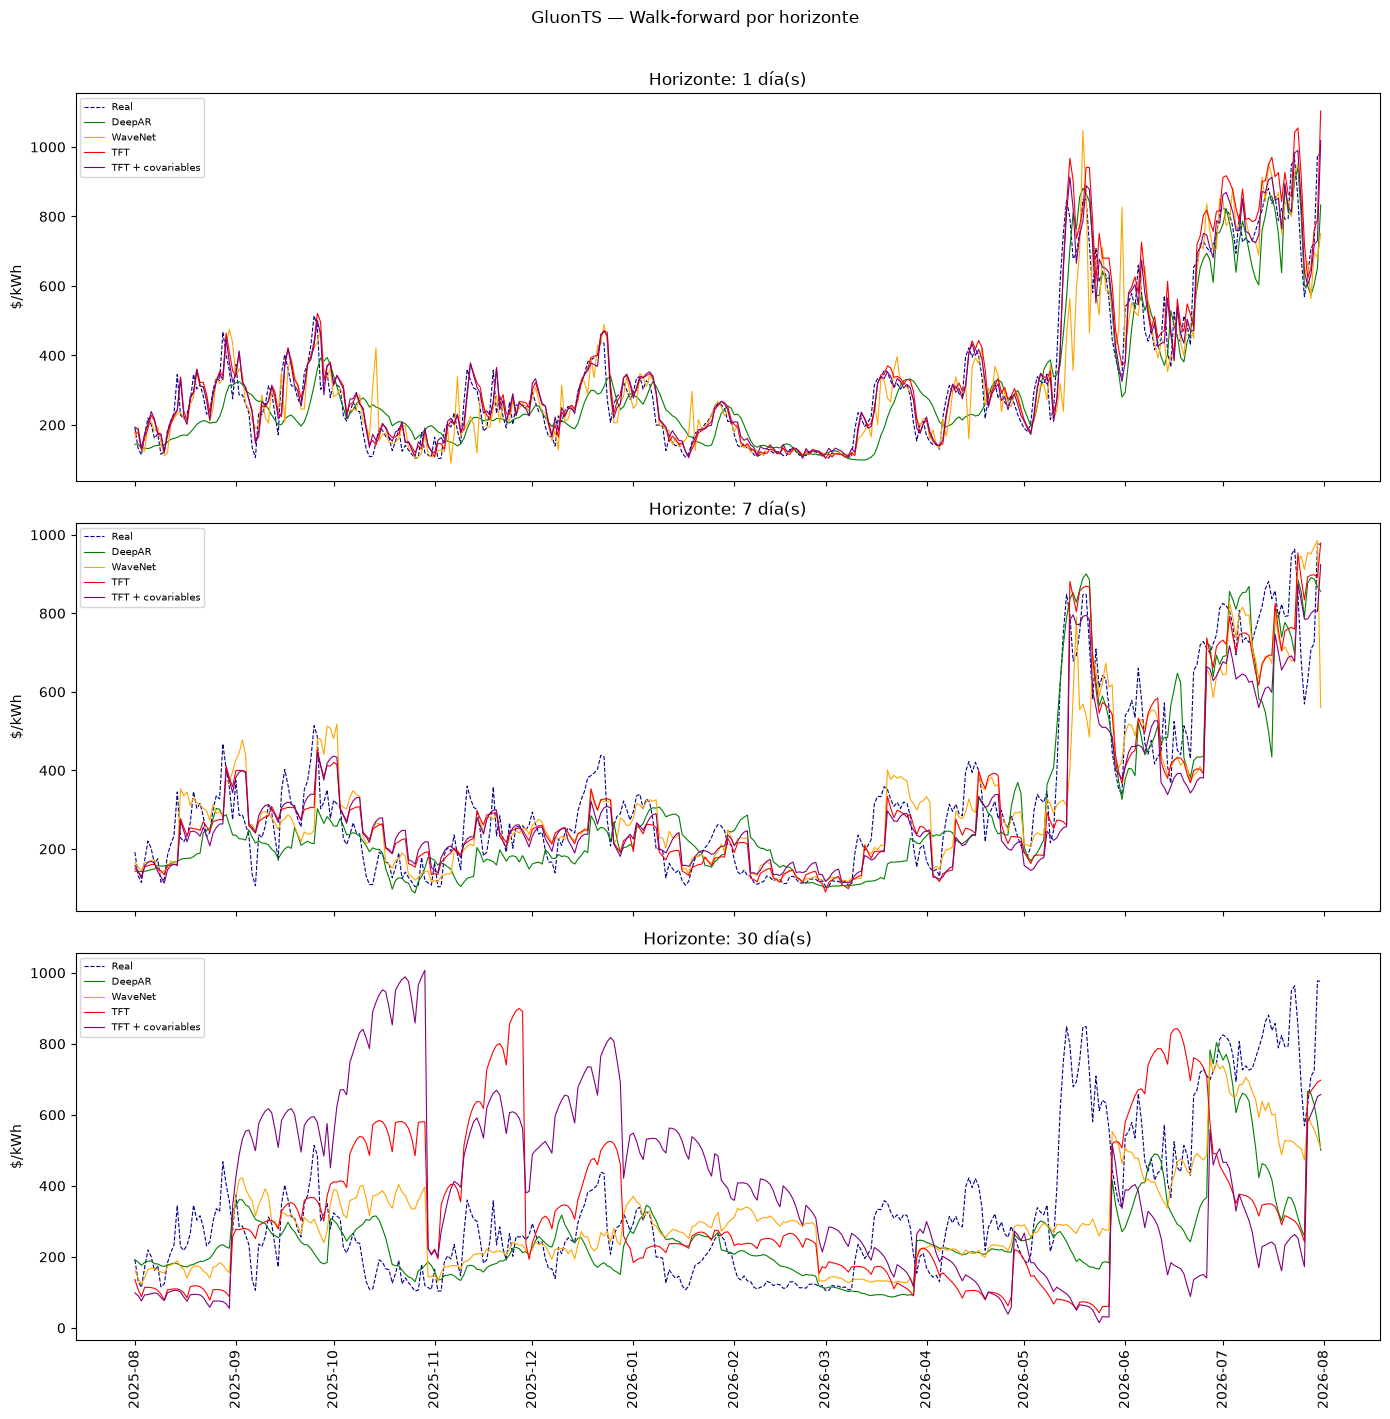

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)
colores = {'DeepAR': 'green', 'WaveNet': 'orange', 'TFT': 'red', 'TFT + covariables': 'purple'}

for ax, h in zip(axes, [1, 7, 30]):
    ax.plot(test_data.index, test_data.values, color='darkblue', linewidth=0.8, linestyle='--', label='Real')
    for modelo in ['DeepAR', 'WaveNet', 'TFT', 'TFT + covariables']:
        pred_df = resultados_todos[(modelo, h)]
        ax.plot(pred_df.index, pred_df['y_pred'], color=colores[modelo], linewidth=0.8, label=modelo)
    ax.set_ylabel('$/kWh')
    ax.set_title(f'Horizonte: {h} día(s)')
    ax.legend(fontsize=7)

axes[-1].tick_params(axis='x', rotation=90)
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.suptitle('GluonTS — Walk-forward por horizonte', y=1.01)
plt.tight_layout()
plt.show()

In [8]:
# Resumen de todo lo guardado en esta corrida
tabla_resumen = pd.read_parquet(archivo_tabla)
tabla_resumen = tabla_resumen[tabla_resumen['Modelo'].isin(['DeepAR', 'WaveNet', 'TFT', 'TFT + covariables'])]

for h in [1, 7, 30]:
    print(f"\n{'='*70}\nHorizonte: {h} día(s)\n{'='*70}")
    vista = tabla_resumen[tabla_resumen['Horizonte'] == h].set_index('Modelo').sort_values('MAE')
    print(vista[['MAE', 'RMSE', 'MAPE (%)', 'sMAPE (%)', 'R²']].to_string())


Horizonte: 1 día(s)
                     MAE   RMSE  MAPE (%)  sMAPE (%)      R²
Modelo                                                      
TFT + covariables  38.97  55.19     13.81      12.90  0.9320
TFT                45.61  65.02     14.88      13.85  0.9056
WaveNet            53.10  84.92     17.44      16.84  0.8390
DeepAR             66.68  86.41     24.66      24.23  0.8333

Horizonte: 7 día(s)
                     MAE    RMSE  MAPE (%)  sMAPE (%)      R²
Modelo                                                       
TFT                66.41   94.71     22.10      21.78  0.7997
WaveNet            73.81  106.97     23.64      22.45  0.7445
TFT + covariables  74.78  103.16     24.88      24.57  0.7624
DeepAR             82.51  106.80     28.62      29.36  0.7453

Horizonte: 30 día(s)
                      MAE    RMSE  MAPE (%)  sMAPE (%)      R²
Modelo                                                        
WaveNet            120.26  160.42     46.70      39.58  0.4254
DeepAR   

Predicción de 30 días

In [9]:
# Contexto completo (train + test) para el forecast al futuro
target_completo = pd.concat([train_data, test_data])
fechas_futuras_gluon = pd.date_range(test_data.index[-1] + pd.Timedelta(days=1), periods=30, freq='D')

# --- Covariables futuras vía promedio estacional (mismo criterio que SARIMAX) ---
exog_futuro_raw = pd.DataFrame(index=fechas_futuras_gluon, columns=covariables, dtype=float)
for fecha in fechas_futuras_gluon:
    mismo_dia = df[(df.index.month == fecha.month) & (df.index.day == fecha.day) & (df.index < '2026-08-01')]
    for cov in covariables:
        exog_futuro_raw.loc[fecha, cov] = mismo_dia[cov].mean()

exog_futuro_scaled = pd.DataFrame(
    scaler_cov.transform(exog_futuro_raw[covariables]),
    index=fechas_futuras_gluon, columns=covariables
)

covariables_hist_scaled = df_scaled.loc[train_data.index[0]:test_data.index[-1], covariables]
feat_dynamic_completo = pd.concat([covariables_hist_scaled, exog_futuro_scaled])

/var/folders/vz/dknzsyq13c55x4nb5c75hmn40000gn/T/ipykernel_1396/807125541.py:3: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  fechas_futuras_gluon = pd.date_range(test_data.index[-1] + pd.Timedelta(days=1), periods=30, freq='D')


In [10]:
# --- Forecast al futuro: DeepAR, WaveNet, TFT (sin covariables) ---
contexto_ds_futuro = ListDataset([{
    "target": target_completo.values,
    "start": target_completo.index[0]
}], freq=FREQ)

forecast_deepar_futuro = list(predictor.predict(contexto_ds_futuro))[0]
forecast_wn_futuro = list(predictor_wn.predict(contexto_ds_futuro))[0]
forecast_tft_futuro = list(predictor_tft.predict(contexto_ds_futuro))[0]

# --- Forecast al futuro: TFT + covariables ---
contexto_ds_tft_cov_futuro = ListDataset([{
    "target": target_completo.values,
    "start": target_completo.index[0],
    "feat_dynamic_real": feat_dynamic_completo[covariables].values.T
}], freq=FREQ)

forecast_tft_cov_futuro = list(predictor_tft_cov.predict(contexto_ds_tft_cov_futuro))[0]

print(f"Forecasts generados: {fechas_futuras_gluon[0].date()} → {fechas_futuras_gluon[-1].date()}")

/opt/anaconda3/envs/tesis-bolsa/lib/python3.12/site-packages/gluonts/torch/util.py:205: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:355.)
  return a[idx]


Forecasts generados: 2026-08-01 → 2026-08-30


NameError: name 'sns' is not defined

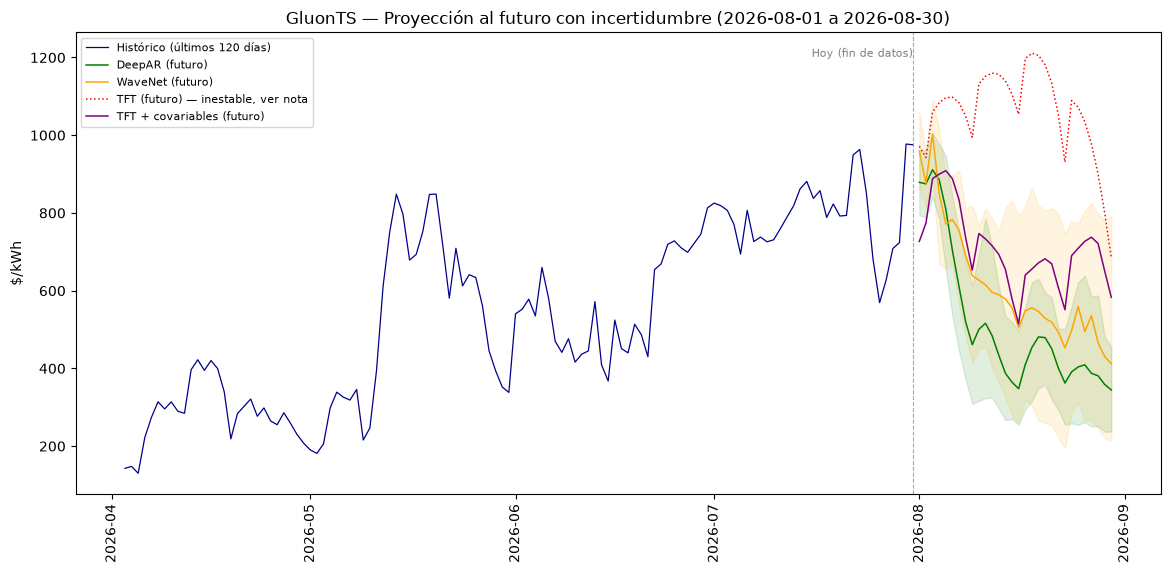

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))

contexto_reciente = target_completo[-120:]
ax.plot(contexto_reciente.index, contexto_reciente.values, color='darkblue', linewidth=0.9, label='Histórico (últimos 120 días)')

ax.plot(fechas_futuras_gluon, forecast_deepar_futuro.mean, color='green', linewidth=1.1, label='DeepAR (futuro)')
ax.plot(fechas_futuras_gluon, forecast_wn_futuro.mean, color='orange', linewidth=1.1, label='WaveNet (futuro)')
ax.plot(fechas_futuras_gluon, forecast_tft_futuro.mean, color='red', linewidth=1.1, linestyle=':', label='TFT (futuro) — inestable, ver nota')
ax.plot(fechas_futuras_gluon, forecast_tft_cov_futuro.mean, color='purple', linewidth=1.1, label='TFT + covariables (futuro)')

# Banda de incertidumbre solo para DeepAR y WaveNet (los estables a 30 días)
ax.fill_between(fechas_futuras_gluon, forecast_deepar_futuro.quantile(0.1), forecast_deepar_futuro.quantile(0.9),
                 alpha=0.12, color='green')
ax.fill_between(fechas_futuras_gluon, forecast_wn_futuro.quantile(0.1), forecast_wn_futuro.quantile(0.9),
                 alpha=0.12, color='orange')

ax.axvline(target_completo.index[-1], color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.text(target_completo.index[-1], ax.get_ylim()[1]*0.95, 'Hoy (fin de datos)', fontsize=8, color='gray', ha='right')

ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title(f'GluonTS — Proyección al futuro con incertidumbre ({fechas_futuras_gluon[0].date()} a {fechas_futuras_gluon[-1].date()})')
sns.despine()
plt.tight_layout()
plt.show()